# Lab 05: The Dark Companion, Two Years Later

**ASTR 457, Fall 2026, posted Sat Oct 3, due Fri Oct 9 by Noon (extended) (fork → PR, as always)**

*Why this lab: every orbit in the literature, from Gaia's black-hole binaries to the planets David Charbonneau talked about on Tuesday, is a posterior distribution over six or seven parameters that nobody can write down in closed form. Sampling it, knowing when the sampler has actually converged, and turning the samples into a number with an honest error bar is the core professional skill of modern astrophysics, and the place where confident, fluent, wrong analyses are most common.*

On Day 1 you watched a star's radial velocity drift over ten nights and inferred an unseen companion from
the slope alone. This is that programme, two and a half years on. Every one of you has your own star:
`data/<your netid>.csv`, with columns `t_days` (time of each spectrum, from the first epoch), `rv_kms`
(the measured radial velocity) and `sigma_rv_kms` (the pipeline's per-epoch uncertainty). The star was
observed in three observing seasons over about 900 days, 28 to 44 epochs in all. It is a **single-lined
spectroscopic binary**: you see one star's lines, the companion contributes no light, and the visible star
follows a Keplerian orbit,

$$v_r(t) = \gamma + K\left[\cos\big(\nu(t) + \omega\big) + e\cos\omega\right],$$

with period $P$, semi-amplitude $K$, eccentricity $e$, argument of periastron $\omega$, a time of periastron
$T_p$, systemic velocity $\gamma$, and $\nu(t)$ the true anomaly (the angle around the orbit, which you get
from Kepler's equation; a function is provided). What you are really after is the **mass function**

$$f(M) = \frac{P K^3 (1 - e^2)^{3/2}}{2\pi G} = \frac{M_2^3 \sin^3 i}{(M_1 + M_2)^2},$$

a lower limit on the companion's mass, in solar masses. If it comes out above about $3\,M_\odot$ for a
Sun-like primary, you have a black hole candidate, the way Gaia BH1 was found (El-Badry et al. 2023, the Sep 8
colloquium). In the units of your file, $f(M) = 1.0361\times10^{-7}\,(1-e^2)^{3/2} K^3 P$ with $K$ in km/s
and $P$ in days.

I know your true $P$, $K$, $e$ and $f(M)$. You don't, your classmates' stars are different, and so is the
sampling. **One more thing I know and you don't: the quoted `sigma_rv_kms` is not the whole error.** Real
radial velocities carry an extra scatter, called jitter, from the star's own surface and from template
mismatch, and it is not in the pipeline number.

**How this is graded.** As always, on whether your answers are *right* and your uncertainties are *honest*:
your reported $P$, $K$, $e$ and $f(M)$ are compared to your truth in units of your own reported uncertainty.
Anti-sandbagging cap: your $\sigma_K$ may not exceed $3\times$ a reference posterior width I compute for your
dataset. Padded error bars lose points like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document it in Part 4. You
may be selected to defend this lab orally; the defense is easy if you did the work.

Weights: Part 1 15%, Part 2 40%, Part 3 35%, Part 4 10%.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.optimize import minimize
from astropy.timeseries import LombScargle

NETID = 'elinas2'   # <-- set this
d = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True)
t, rv, sig = d['t_days'], d['rv_kms'], d['sigma_rv_kms']
print(f"{t.size} epochs over {t.max() - t.min():.0f} days; median quoted error {np.median(sig):.2f} km/s")

def kepler_rv(t, P, K, e, omega, Tp, gamma):
    """Radial velocity of the visible star in a Keplerian orbit.
    P period [d], K semi-amplitude [km/s], e eccentricity, omega argument of periastron [rad],
    Tp a time of periastron [d], gamma systemic velocity [km/s]. Solves Kepler's equation by Newton iteration."""
    M = 2. * np.pi * ((t - Tp) / P % 1.0)            # mean anomaly
    E = M.copy()                                     # eccentric anomaly
    for _ in range(30):
        E = E - (E - e * np.sin(E) - M) / (1. - e * np.cos(E))
    nu = 2. * np.arctan2(np.sqrt(1. + e) * np.sin(E / 2.), np.sqrt(1. - e) * np.cos(E / 2.))   # true anomaly
    return gamma + K * (np.cos(nu + omega) + e * np.cos(omega))

def mass_function(P, K, e):
    """f(M) in solar masses, for P in days and K in km/s."""
    return 1.0361e-7 * (1. - e**2)**1.5 * K**3 * P

28 epochs over 848 days; median quoted error 1.53 km/s


## Part 1: Look first, then find the period (15%)

Plot the radial velocities against time with their error bars. Then find candidate orbital periods with a
Lomb-Scargle periodogram of the velocities (`astropy.timeseries.LombScargle`, Day 7's periodogram, formally
taught on Oct 20/22; for now it is a tool that ranks periods). Plot the periodogram. Then, for the best two or
three candidate periods, phase-fold the data and look.

Answer, in a few sentences: how many candidate periods are plausible from the periodogram alone, and why does
a Lomb-Scargle periodogram (which fits a *sinusoid*) not settle the question for an eccentric orbit? What
feature of the sampling (look at the gaps) produces the other peaks?


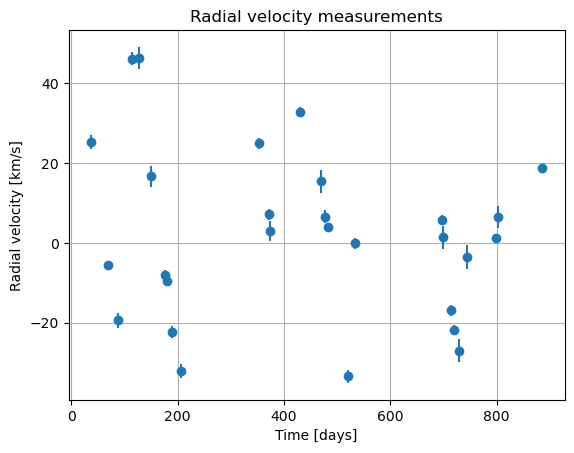

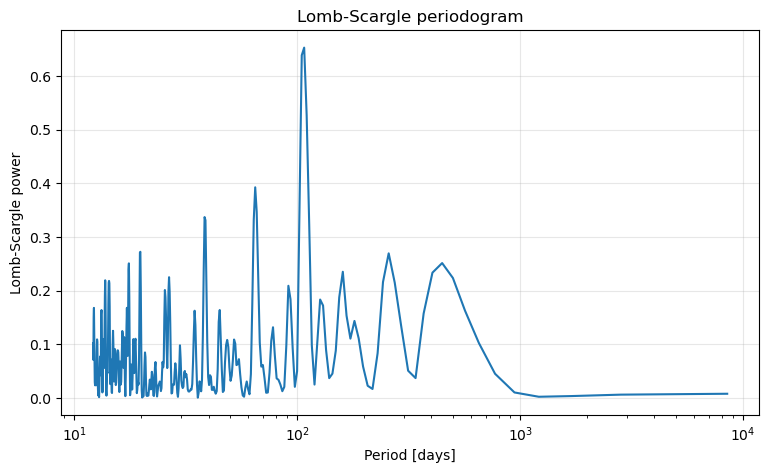

Candidate periods [days]: [107.39278481012659, 64.76358778625954, 38.38927601809955]


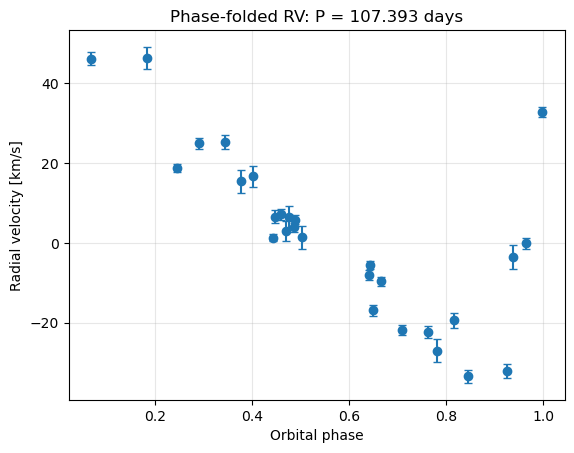

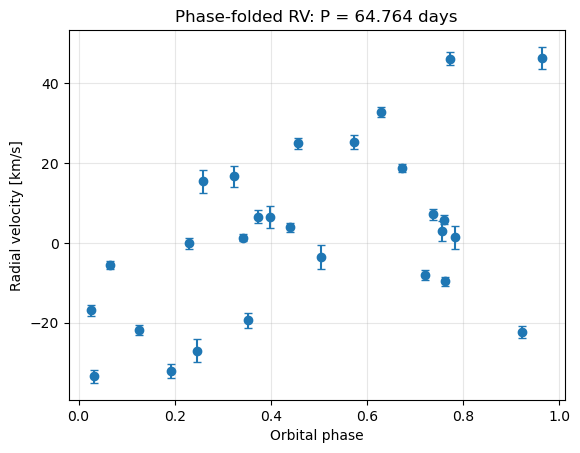

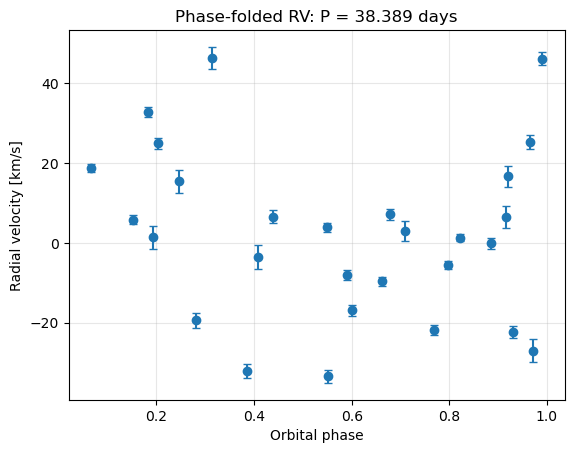

In [65]:
# Part 1: your work here

plt.errorbar(t,rv,yerr=sig,fmt='o')
plt.xlabel('Time [days]')
plt.ylabel('Radial velocity [km/s]')
plt.title('Radial velocity measurements')
plt.grid()
plt.show()

baseline=t.max()-t.min()
ls=LombScargle(t,rv,sig)
frequency,power=ls.autopower()
period=1./frequency
plt.figure(figsize=(9,5))
plt.plot(period,power)
plt.xlabel('Period [days]')
plt.ylabel('Lomb-Scargle power')
plt.title('Lomb-Scargle periodogram')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.show()

idx_sorted=np.argsort(power)[::-1]
candidate_periods=[]
for idx in idx_sorted:
    P=period[idx]
    if all(abs(P-Pc)/Pc>0.05 for Pc in candidate_periods): candidate_periods.append(P)
    if len(candidate_periods)==3: break
print("Candidate periods [days]:",candidate_periods)

for P in candidate_periods:
    phase=(t%P)/P; s=np.argsort(phase)
    plt.errorbar(phase[s],rv[s],yerr=sig[s],fmt='o',capsize=3)
    plt.xlabel('Orbital phase'); plt.ylabel('Radial velocity [km/s]')
    plt.title(f'Phase-folded RV: P = {P:.3f} days')
    plt.grid(alpha=0.3)
    plt.show()

**ANSWER (a few sentences):**

how many candidate periods are plausible from the periodogram alone: the periodgram finds 3 plausible periods, but the P=107 looks most promising.

why does a Lomb-Scargle periodogram (which fits a sinusoid) not settle the question for an eccentric orbit? Lomb–Scargle fits sinusoidal signals, while the radial-velocity curve of an eccentric binary can asymmteric, which the LS doesnt take intp account. 

What feature of the sampling (look at the gaps) produces the other peaks?additional peaks are produced by the uneven time sampling and large gaps in the observations

## Part 2: Sample the posterior (40%)

Fit the six orbital parameters **plus a jitter term** $s$ with `emcee`. The likelihood for epoch $i$ is
Gaussian with variance $\sigma_i^2 + s^2$; write it out (including the $\log$ of the variance, which is not a
constant once $s$ is a parameter). You will need to:

1. **Write the log-likelihood, log-prior and log-posterior.** State every prior and justify it in one line
   each. Two traps: $\omega$ and $T_p$ are periodic ($T_p$ is only defined modulo $P$), and `emcee` does not
   wrap angles, so a hard prior wall at $0$ or $2\pi$ can cut a posterior mode in half. Either bound each of
   them within half a period of your starting value, or reparameterize with $\sqrt{e}\cos\omega$ and
   $\sqrt{e}\sin\omega$ (which also gives a uniform prior on $e$ without a wall at zero). Jitter is
   positive: sample $\ln s$.
2. **Start the walkers sensibly.** A maximum-likelihood fit from each plausible Part 1 period, with several
   starting $\omega$ and $T_p$ each, then compare the log-likelihoods; start the walkers in a small ball
   around the best one. That comparison is the check: report the log-likelihood of the runner-up.
3. **Run, then decide when it is done.** Compute the integrated autocorrelation time $\tau$ for every
   parameter (`sampler.get_autocorr_time`). Here $\tau$ is about 50 to 100 steps, so 64 walkers for
   10,000 steps is plenty (a few minutes) and `emcee`'s own rule is a chain longer than $50\tau$. A
   common choice is to discard a few $\tau$ as burn-in and thin by about $\tau/2$; say what you chose
   and why. Plot the chains. If $\tau$ cannot be estimated, your chain is too short; say so and fix it.
4. **Corner plot.** Which parameters are correlated, and why physically?
5. **Report** $P$, $K$, $e$, $\gamma$, the jitter $s$, and $f(M)$, each as a median and 68% interval.
   **$f(M)$ is computed for every posterior sample**, not from the medians of $P$, $K$ and $e$; explain in
   one sentence why that matters.
6. **Posterior predictive check.** Draw a few hundred orbits from the posterior and plot them over the data,
   phase-folded at the median period. Plot the normalized residuals with the *total* error bar
   $\sqrt{\sigma_i^2 + s^2}$. Is what is left noise?

**FINAL ANSWER:** $P = $ ___ $\pm$ ___ d, $K = $ ___ $\pm$ ___ km/s, $e = $ ___ $\pm$ ___, $\gamma = $ ___ $\pm$ ___ km/s, jitter $s = $ ___ $\pm$ ___ km/s, $f(M) = $ ___ $\pm$ ___ $M_\odot$. Is your companion a black-hole candidate? One sentence.


## priors
P>0: has to be positive.
K>0: radial-velocity semi-amplitude is physically positive.
0< e<0.95: eccentricity must lie below 1 for a bound orbit, with 0.95 avoiding numerical problems extremely close to unity.
omega: restricted to one continuous 2pi interval centered on the starting solution because the angle is periodic.
Tp:restricted to Tp0+-P/2 because periastron time is only defined modulo P
gamma: broad uniform interval 
ln s: broad uniform prior in log-jitter because smust be positive and may span orders of magnitude

In [ ]:
# Part 2: your work here
def log_likelihood(theta):
    P,K,e,omega,Tp,gamma,lns=theta
    s=np.exp(lns)
    var=sig**2+s**2
    model=kepler_rv(t,P,K,e,omega,Tp,gamma)
    return -0.5*np.sum((rv-model)**2/var+np.log(2*np.pi*var))

def log_prior(theta):
    P,K,e,omega,Tp,gamma,lns=theta
    
    if not 0<P:
        return -np.inf
    if not 0<K<1000:
        return -np.inf
    if not 0<=e:
        return -np.inf
    if not omega0-np.pi<omega<omega0+np.pi:
        return -np.inf
    if not Tp0-0.5*P0<Tp<Tp0+0.5*P0:
        return -np.inf
    if not np.log(1e-3)<lns<np.log(50):
        return -np.inf
    
    return 0.0

def log_posterior(theta):
    lp=log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp+log_likelihood(theta)



In [ ]:
starts=[]

for P0 in candidate_periods:
    for omega0 in np.linspace(-np.pi,np.pi,5)[:-1]:
        for frac in [0.0,0.25,0.5,0.75]:
            Tp0=t.min()+frac*P0
            theta0=np.array([P0,0.5*(rv.max()-rv.min()),0.3,omega0,Tp0,np.mean(rv),np.log(np.median(sig))])
            
            bounds=[
                (0.5*P0,1.5*P0),
                (1e-3,1000),
                (0,0.95),
                (omega0-np.pi,omega0+np.pi),
                (Tp0-0.5*P0,Tp0+0.5*P0),
                (rv.min()-200,rv.max()+200),
                (np.log(1e-3),np.log(100))
            ]
            
            result=minimize(lambda x:-log_likelihood(x),theta0,bounds=bounds,method='Nelder-Mead')
            
            if result.success:
                starts.append((log_likelihood(result.x),result.x))

starts=sorted(starts,key=lambda x:x[0],reverse=True)

best_ll,best=starts[0]
runner_ll,runner=starts[1]

print("Best log-likelihood:",best_ll)
print("Best parameters:",best)
print("Runner-up log-likelihood:",runner_ll)
print("Runner-up parameters:",runner)

P0,K0,e0,omega0,Tp0,gamma0,lns0=best
ndim=7
nwalkers=64
nsteps=10000

rng=np.random.default_rng(3)
scale = 1e-4*np.maximum(np.abs(best),1)

theta_start=best+scale*rng.normal(size=(nwalkers,ndim))

100%|████████████████████████████████████████████████████████████████████████████| 10000/10000 [08:14<00:00, 20.21it/s]


Autocorrelation times:
[73.3626635  75.69192879 77.3967258  74.63436347 70.11087041 76.18373901
 77.45895026]
Chain length / max tau: 129.10063931954716
Mean acceptance fraction: 0.4855109375


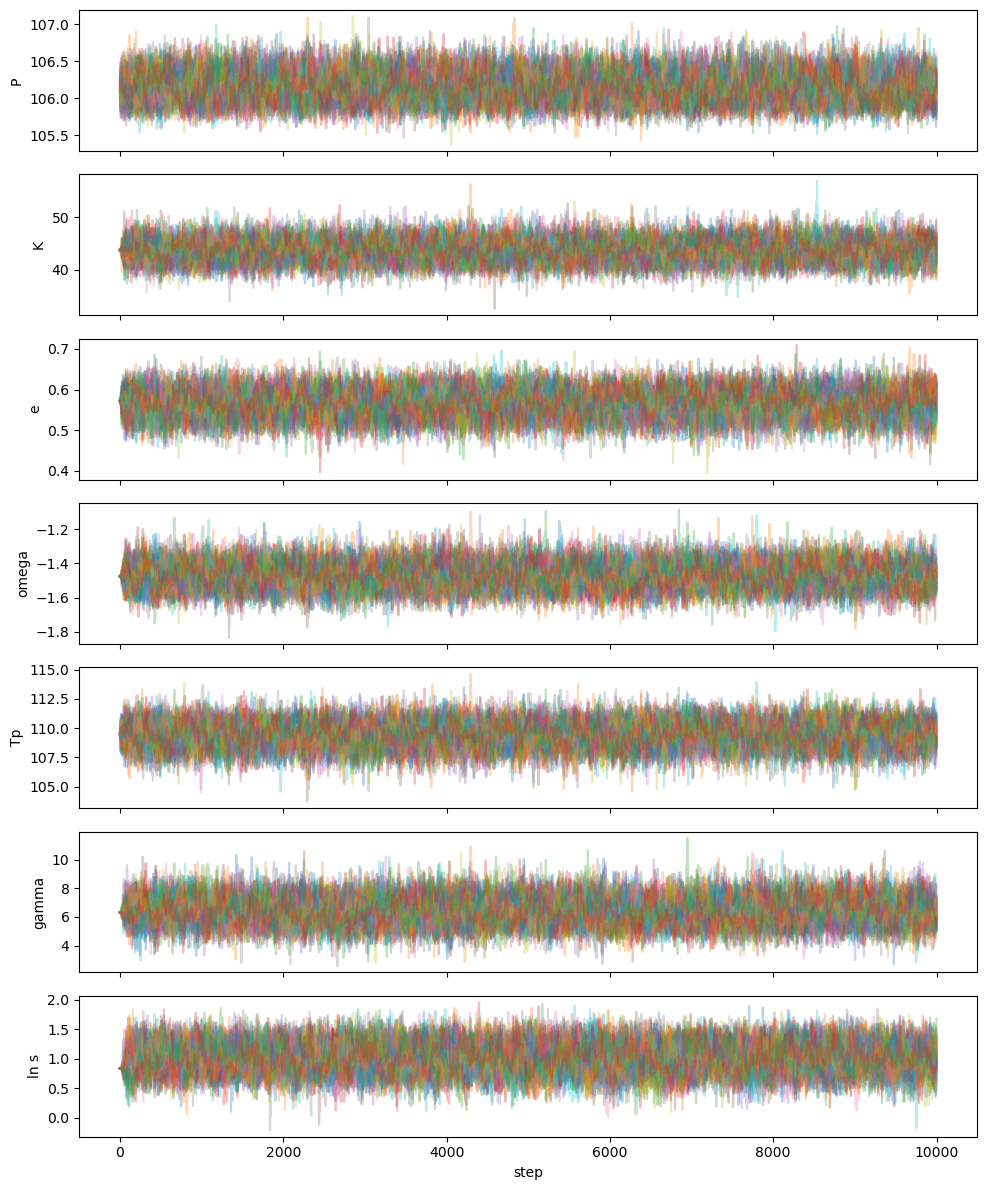

In [36]:
np.random.seed(12)

sampler=emcee.EnsembleSampler(nwalkers,ndim,log_posterior)
sampler.run_mcmc(theta_start,nsteps,progress=True)
tau=sampler.get_autocorr_time()

print("Autocorrelation times:")
print(tau)
print("Chain length / max tau:",nsteps/tau.max())
print("Mean acceptance fraction:",sampler.acceptance_fraction.mean())
labels=['P','K','e','omega','Tp','gamma','ln s']

chain=sampler.get_chain()

fig,axes=plt.subplots(ndim,1,figsize=(10,12),sharex=True)

for i in range(ndim):
    axes[i].plot(chain[:,:,i],alpha=0.3)
    axes[i].set_ylabel(labels[i])

axes[-1].set_xlabel('step')
plt.tight_layout()
plt.show()

In [49]:
burn=int(3*tau.max())
thin=max(1,int(tau.max()/2))
samples=sampler.get_chain(discard=burn,thin=thin,flat=True)

print("burn =",burn)
print("thin =",thin)
print("samples shape =",samples.shape)

burn = 232
thin = 38
samples shape = (16448, 7)


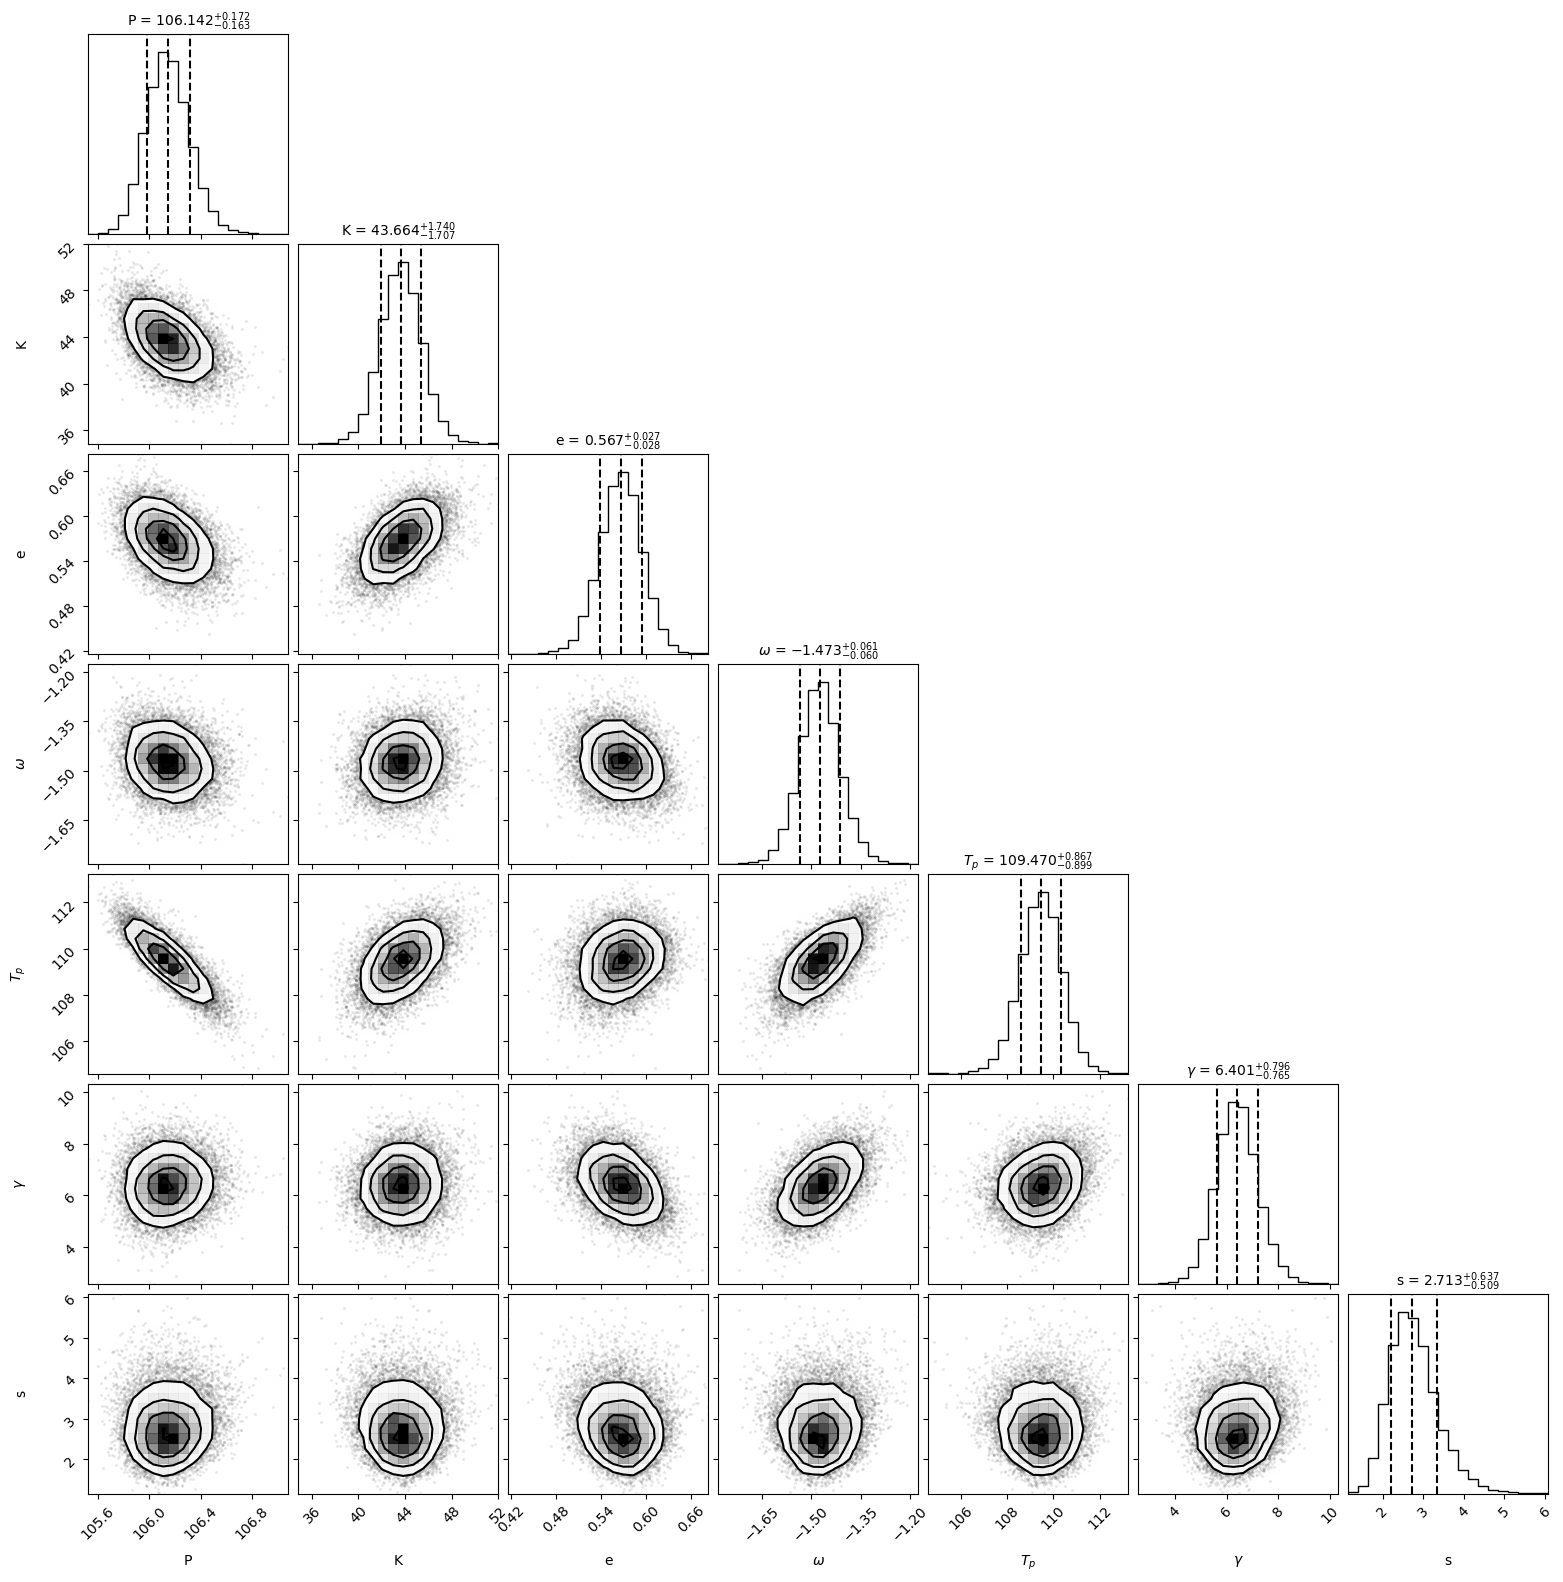

In [51]:
P_s=samples[:,0]
K_s=samples[:,1]
e_s=samples[:,2]
omega_s=samples[:,3]
Tp_s=samples[:,4]
gamma_s=samples[:,5]
s_s=np.exp(samples[:,6])

physical_samples=np.column_stack((P_s,K_s,e_s,omega_s,Tp_s,gamma_s,s_s))

labels=['P','K','e',r'$\omega$',r'$T_p$',r'$\gamma$','s']

fig=corner.corner(physical_samples,labels=labels,show_titles=True,quantiles=[0.16,0.5,0.84],title_fmt='.3f',title_kwargs={'fontsize':10})
plt.show()

k ande are correlated because both affect the velocity extrema and the shape of the eccentric RV curve. \omega and tp both control the phase/location of periastron in the observed RV curve and therefore trade off against each other. The jitter is comparatively independent of the orbital parameters, indicating that it mainly accounts for additional random scatter rather than changing the inferred orbit.

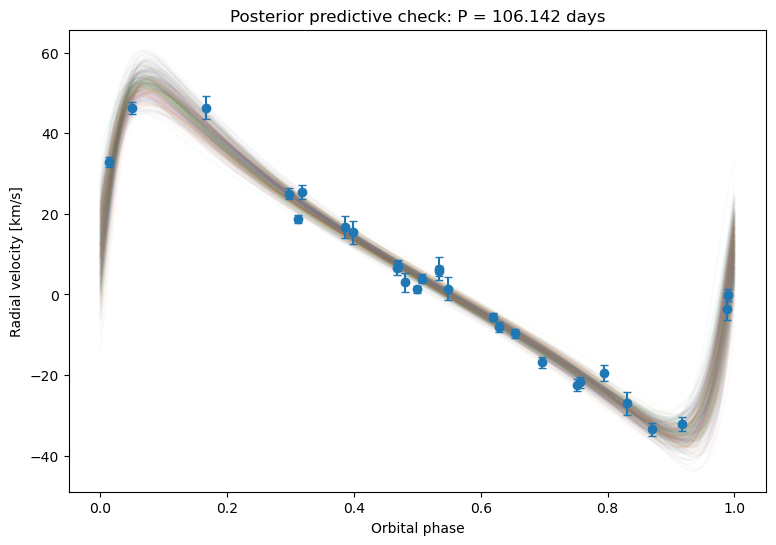

In [53]:

Pmed=np.median(P_s)
Tpmed=np.median(Tp_s)
phase=((t-Tpmed)/Pmed)%1
phase_grid=np.linspace(0,1,500)
t_grid=Tpmed+phase_grid*Pmed

rng=np.random.default_rng(42)
idx=rng.choice(len(samples),size=min(300,len(samples)),replace=False)

plt.figure(figsize=(9,6))

for j in idx:
    P,K,e,omega,Tp,gamma,lns=samples[j]
    model=kepler_rv(t_grid,P,K,e,omega,Tp,gamma)
    plt.plot(phase_grid,model,alpha=0.03)

order=np.argsort(phase)
plt.errorbar(phase[order],rv[order],yerr=sig[order],fmt='o',capsize=3)

plt.xlabel('Orbital phase')
plt.ylabel('Radial velocity [km/s]')
plt.title(f'Posterior predictive check: P = {Pmed:.3f} days')
plt.show()

In [86]:
fM_s=mass_function(P_s,K_s,e_s)
def report(x,name):
    q16,q50,q84=np.percentile(x,[16,50,84])
    print(f"{name} = {q50:.4f} +{q84-q50:.4f} -{q50-q16:.4f}")

report(P_s,"P [days]")
report(K_s,"K [km/s]")
report(e_s,"e")
report(gamma_s,"gamma [km/s]")
report(s_s,"s [km/s]")
report(fM_s,"f(M) [Msun]")

P [days] = 106.1417 +0.1717 -0.1627
K [km/s] = 43.6644 +1.7398 -1.7069
e = 0.5670 +0.0275 -0.0283
gamma [km/s] = 6.4013 +0.7962 -0.7653
s [km/s] = 2.7132 +0.6370 -0.5092
f(M) [Msun] = 0.5099 +0.0542 -0.0494


fmmust be calculated for every posterior sample because it is a nonlinear function of the correlated parameters p,kand e.

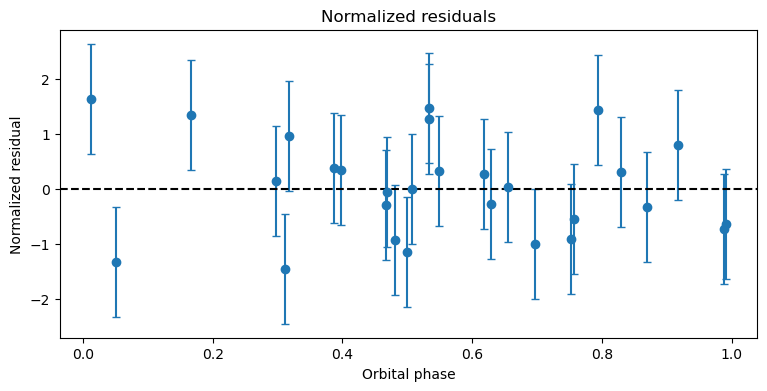

Residual mean: 0.03417013519530352
Residual standard deviation: 0.8825283094964098


In [55]:
med=np.median(samples,axis=0)
P,K,e,omega,Tp,gamma,lns=med
s=np.exp(lns)

model=kepler_rv(t,P,K,e,omega,Tp,gamma)
resid=(rv-model)/np.sqrt(sig**2+s**2)

plt.figure(figsize=(9,4))
plt.errorbar(phase[order],resid[order],yerr=np.ones(len(resid)),fmt='o',capsize=3)
plt.axhline(0,color='k',ls='--')
plt.xlabel('Orbital phase')
plt.ylabel('Normalized residual')
plt.title('Normalized residuals')
plt.show()

print("Residual mean:",np.mean(resid))
print("Residual standard deviation:",np.std(resid))

**FINAL ANSWER:** $P = $ ___ $\pm$ ___ d, $K = $ ___ $\pm$ ___ km/s, $e = $ ___ $\pm$ ___ , $\gamma = $ ___ $\pm$ ___ km/s, $s = $ ___ $\pm$ ___ km/s, $f(M) = $ ___ $\pm$ ___ $M_\odot$

**Black-hole candidate?** No? Not bigger than 3Msun.

## Part 3: The referee report (35%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident MCMC analysis of this exact
problem, produced by an AI assistant. It runs top to bottom without errors, the corner plot is handsome, and
the prose is fluent. It is also wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks and
style don't count; "it used 24 walkers and I used 32" is not a finding).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset: show, with a number or a plot, what the error
   does to the inference. For a sampler, "demonstrate" usually means running it the wrong way and the right
   way and comparing. A demonstration can come out negative: if an error turns out not to move *your*
   numbers, showing that, and saying what it would take for it to bite, is a valid finding.
3. **State** the correct treatment (you built it in Part 2).

Third time you have done this. You should be finding these in minutes now.


In [ ]:
# Part 3: your work here
mode_fits=[]

for Pstart in candidate_periods:
    local=[]
    for ostart in np.linspace(-np.pi,np.pi,5)[:-1]:
        for frac in [0,.25,.5,.75]:
            Tstart=t.min()+frac*Pstart
            x0=np.array([Pstart,0.5*(rv.max()-rv.min()),0.3,ostart,Tstart,np.mean(rv),np.log(np.median(sig))])
            bounds=[(0.5*Pstart,1.5*Pstart),(1e-3,1000),(0,.95),
                    (ostart-np.pi,ostart+np.pi),(Tstart-.5*Pstart,Tstart+.5*Pstart),
                    (rv.min()-200,rv.max()+200),(np.log(1e-3),np.log(100))]
            r=minimize(lambda x:-log_likelihood(x),x0,bounds=bounds,method='Nelder-Mead')
            if r.success: local.append((log_likelihood(r.x),r.x))
    local=sorted(local,key=lambda x:x[0],reverse=True)
    mode_fits.append(local[0])

for ll,x in mode_fits:
    print(f"P={x[0]:.3f} d   logL={ll:.2f}")

mode_fits=sorted(mode_fits,key=lambda x:x[0],reverse=True)
best_mode=mode_fits[0][1]
other_mode=mode_fits[1][1]
def run_from_mode(center,nsteps=10000):
    scale=np.array([1e-3*center[0],1e-3*max(center[1],1),1e-3,1e-3,
                    1e-3*center[0],1e-3*max(abs(center[5]),1),1e-3])
    rng=np.random.default_rng(10)
    p=center+scale*rng.normal(size=(64,7))
    s=emcee.EnsembleSampler(64,7,log_posterior)
    s.run_mcmc(p,nsteps,progress=True)
    return s

sampler_best=run_from_mode(best_mode)
sampler_other=run_from_mode(other_mode)
P_best=sampler_best.get_chain(discard=2000,flat=True)[:,0]
P_other=sampler_other.get_chain(discard=2000,flat=True)[:,0]

print("Started best mode: ",np.percentile(P_best,[16,50,84]))
print("Started other mode:",np.percentile(P_other,[16,50,84]))

plt.hist(P_best,bins=40,density=True,alpha=.5,label='started at best mode')
plt.hist(P_other,bins=40,density=True,alpha=.5,label='started at other mode')
plt.xlabel('P [days]')
plt.legend()
plt.show()

P=106.123 d   logL=-69.48
P=64.245 d   logL=-120.67
P=38.691 d   logL=-120.91


 81%|██████████████████████████████████████████████████████████████▌              | 8118/10000 [06:21<01:18, 24.06it/s]

In [ ]:
def log_likelihood_nojitter(theta):
    P,K,e,omega,Tp,gamma=theta
    model=kepler_rv(t,P,K,e,omega,Tp,gamma)
    return -0.5*np.sum((rv-model)**2/sig**2+np.log(2*np.pi*sig**2))

def log_prior_nojitter(theta):
    P,K,e,omega,Tp,gamma=theta
    if not 0.5*P0<P<1.5*P0: return -np.inf
    if not 0<K<1000: return -np.inf
    if not 0<=e<0.95: return -np.inf
    if not omega0-np.pi<omega<omega0+np.pi: return -np.inf
    if not Tp0-.5*P0<Tp<Tp0+.5*P0: return -np.inf
    if not rv.min()-200<gamma<rv.max()+200: return -np.inf
    return 0.

def log_post_nojitter(theta):
    lp=log_prior_nojitter(theta)
    if not np.isfinite(lp): return -np.inf
    return lp+log_likelihood_nojitter(theta)

center6=best[:6]

scale6=np.array([1e-3*center6[0],1e-3*center6[1],1e-3,1e-3,
                 1e-3*center6[0],1e-3*max(abs(center6[5]),1)])

rng=np.random.default_rng(20)
start6=center6+scale6*rng.normal(size=(64,6))

sampler6=emcee.EnsembleSampler(64,6,log_post_nojitter)
sampler6.run_mcmc(start6,30000,progress=True)
tau6=sampler6.get_autocorr_time()
samples6=sampler6.get_chain(discard=int(3*tau6.max()),
                            thin=max(1,int(tau6.max()/2)),flat=True)

names=['P','K','e','omega','Tp','gamma']

for i,name in enumerate(names):
    a=np.percentile(samples[:,i],[16,50,84])
    b=np.percentile(samples6[:,i],[16,50,84])
    print(name)
    print("with jitter :",a)
    print("no jitter   :",b)

plt.hist(r_nojitter,bins=12,alpha=.5,label='no jitter')
plt.hist(resid,bins=12,alpha=.5,label='with jitter')
plt.xlabel('Normalized residual')
plt.legend()
plt.show()

**REFEREE REPORT:**

1. it says Initializing the walkers in a tight ball around the MAP estimate ensures rapid convergence" which is what we decinded in lecture is a mistake, have to search broadly rather than finding a single solution
2. it does not include a jitter term in its likelihood
3. it computes tau = sampler.get_autocorr_time(tol=0). tol=0 forces emcee to return an autocorrelation-time estimate even when the chain may be too short for a reliable estimate

## Part 4: AI-use appendix and verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did you catch it? Honesty
   is graded; "I didn't use any" is fine if true.
2. **Reflection (new from this lab on, two or three sentences)**: what did you use AI for in this lab, and
   what would have gone wrong in your answer if you had not checked its output? Name the specific thing, not
   "it could have made a mistake".
3. **Verification plan**: the checks you ran before trusting your Part 2 numbers, and what failure would have
   looked like for each. One you should seriously consider: generate a synthetic RV curve with parameters
   you choose, at *your* epochs, run your whole Part 2 pipeline on it, and see whether the 68% intervals
   contain what you put in. With seven parameters and one realisation, expect about five of seven inside
   their 68% intervals; one pull of 2.5σ is not a failure by itself. Failure looks systematic: the same
   parameter off in the same direction every time, or an interval that never contains the truth.


**AI-USE APPENDIX:**
Used AI for most of the code, it has a tendency for overcomplicating the code, so I rcompared to the lecture slides. It wanted to be more restrictive on its priors too, which I changed. It wouldve fallen into the same trap as the ai solution otherwise.

**REFLECTION:**

*your answer goes here*

**VERIFICATION PLAN:**



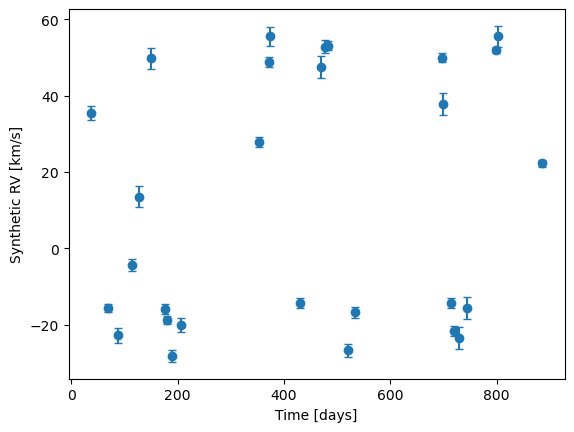

In [57]:
P_true=107.4
K_true=40.0
e_true=0.35
omega_true=1.0
Tp_true=t.min()+20.0
gamma_true=5.0
s_true=2.0

rng=np.random.default_rng(123)

rv_true=kepler_rv(t,P_true,K_true,e_true,omega_true,Tp_true,gamma_true)
rv_syn=rv_true+rng.normal(0,np.sqrt(sig**2+s_true**2))
plt.errorbar(t,rv_syn,yerr=sig,fmt='o',capsize=3)
plt.xlabel('Time [days]')
plt.ylabel('Synthetic RV [km/s]')
plt.show()

In [59]:
def log_likelihood_data(theta,rv_data):
    P,K,e,omega,Tp,gamma,lns=theta
    s=np.exp(lns)
    var=sig**2+s**2
    model=kepler_rv(t,P,K,e,omega,Tp,gamma)
    return -0.5*np.sum((rv_data-model)**2/var+np.log(2*np.pi*var))
    theta0=np.array([
    1.05*P_true,
    0.9*K_true,
    0.25,
    omega_true+0.3,
    Tp_true+5.0,
    gamma_true+2.0,
    np.log(1.5)
])

bounds=[
    (0.5*P_true,1.5*P_true),
    (1e-3,1000),
    (0,0.95),
    (omega_true-np.pi,omega_true+np.pi),
    (Tp_true-0.5*P_true,Tp_true+0.5*P_true),
    (rv_syn.min()-200,rv_syn.max()+200),
    (np.log(1e-3),np.log(100))
]

result=minimize(
    lambda x:-log_likelihood_data(x,rv_syn),
    theta0,
    bounds=bounds,
    method='Nelder-Mead'
)

best_syn=result.x
print(best_syn)
P0,K0,e0,omega0,Tp0,gamma0,lns0=best_syn

def log_prior_syn(theta):
    P,K,e,omega,Tp,gamma,lns=theta
    if not 0.5*P0<P<1.5*P0: return -np.inf
    if not 0<K<1000: return -np.inf
    if not 0<=e<0.95: return -np.inf
    if not omega0-np.pi<omega<omega0+np.pi: return -np.inf
    if not Tp0-0.5*P0<Tp<Tp0+0.5*P0: return -np.inf
    if not rv_syn.min()-200<gamma<rv_syn.max()+200: return -np.inf
    if not np.log(1e-3)<lns<np.log(100): return -np.inf
    return 0.0

def log_posterior_syn(theta):
    lp=log_prior_syn(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp+log_likelihood_data(theta,rv_syn)

C:\Users\ielin\AppData\Local\Temp\ipykernel_30920\3618068416.py:27: OptimizeWarning: Initial guess is not within the specified bounds
  result=minimize(


[53.7        34.68446686  0.77561825  0.616438   52.2256246   3.16377375
  3.24796582]


In [61]:
ndim=7
nwalkers=64
nsteps=10000

scale=np.array([
    1e-3*P0,
    1e-3*max(K0,1),
    1e-3,
    1e-3,
    1e-3*P0,
    1e-3*max(abs(gamma0),1),
    1e-3
])

rng=np.random.default_rng(3)
start_syn=best_syn+scale*rng.normal(size=(nwalkers,ndim))

sampler_syn=emcee.EnsembleSampler(nwalkers,ndim,log_posterior_syn)
sampler_syn.run_mcmc(start_syn,nsteps,progress=True)

tau_syn=sampler_syn.get_autocorr_time()
burn_syn=int(3*tau_syn.max())
thin_syn=max(1,int(tau_syn.max()/2))

samples_syn=sampler_syn.get_chain(
    discard=burn_syn,
    thin=thin_syn,
    flat=True
)
truth=np.array([
    P_true,
    K_true,
    e_true,
    omega_true,
    Tp_true,
    gamma_true,
    s_true
])

syn_phys=samples_syn.copy()
syn_phys[:,6]=np.exp(syn_phys[:,6])

labels=['P','K','e','omega','Tp','gamma','s']

for i,name in enumerate(labels):
    lo,med,hi=np.percentile(syn_phys[:,i],[16,50,84])
    inside=lo<=truth[i]<=hi
    pull=(med-truth[i])/(0.5*(hi-lo))
    print(f'{name:6s}: truth={truth[i]:8.3f}, 68%=[{lo:8.3f},{hi:8.3f}], inside={inside}, pull={pull:6.2f}')

count=0

for i in range(7):
    lo,hi=np.percentile(syn_phys[:,i],[16,84])
    count+=lo<=truth[i]<=hi

print("Truth inside 68% interval for",count,"of 7 parameters")

100%|████████████████████████████████████████████████████████████████████████████| 10000/10000 [05:07<00:00, 32.57it/s]


AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 200;
tau: [458.05154654 538.87520595 506.67554469 464.82591781 502.41829956
 419.66663057 450.20951098]

It failed, 